# **Problem Statement**

You are the Data Scientist at a telecom company “Leo” whose customers are churning out to its
competitors. You have to analyse the data of your company and find insights and stop your customers from
churning out to other telecom companies.

**Importing the necessary Libraries**

In [1]:
import pandas as pd #for data manipulation
import numpy as np # numerical python

#for splitting the data in train and test data
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt #for data visualization
import plotly.express as px #data visualization
import plotly.graph_objects as go
import seaborn as sns

#for model building
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import*

#random module
import random
np.random.seed(44)
tf.random.set_seed(44)

**Importing the dataset**

In [2]:
df=pd.read_csv('/content/customer_churn (1).csv')

**Interpreting the Dataset**

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**The data set includes information about:**
**Customers who left within the last month** – the column is called Churn

**Services that each customer has signed up for**– phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies

**Customer account information** – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

**Demographic info about customers** – gender, age range, and if they have partners and dependents

In [5]:
df.shape

(7043, 21)

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.duplicated().sum()

0

In [8]:
#changing the datatype of total_charges column
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

<ipython-input-10-9c0f9f00c74e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)


In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Data Manipulation**

In [12]:
#a. Find the total number of male customers
df.groupby(['gender'])['customerID'].nunique().iloc[1]

3555

In [13]:
#b. Find the total number of customers whose Internet Service is ‘DSL’
df.groupby(['InternetService'])['customerID'].nunique().iloc[0]

2421

In [14]:
#Extract all the Female senior citizens whose Payment Method is Mailed check & store the result in ‘new_customer’
new_customer=df[(df['gender']=='Female')&(df['PaymentMethod']=='Mailed check')&(df['SeniorCitizen']==1)]
new_customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
139,0390-DCFDQ,Female,1,Yes,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.45,70.45,Yes
176,2656-FMOKZ,Female,1,No,No,15,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.45,1145.70,Yes
267,3197-ARFOY,Female,1,No,No,19,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,105.00,2007.25,No
451,5760-WRAHC,Female,1,No,No,22,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,69.75,1545.40,No
470,4933-IKULF,Female,1,No,No,17,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,330.60,No


In [15]:
#d. Extract all those customers whose tenure is less than 10 months or their Total charges is less
#than 500$ & store the result in ‘new_customer’
new_customer=df[(df['tenure']<10)&(df['TotalCharges']<500)]
new_customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
22,1066-JKSGK,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes


**Data Visualization**

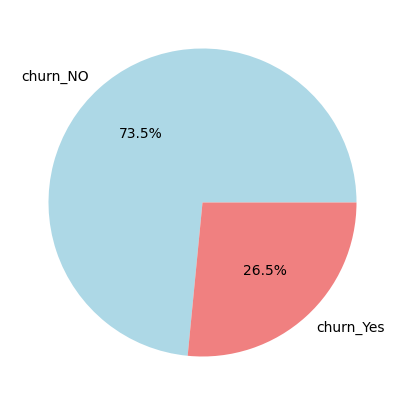

In [16]:
#a. Build a pie-chart to show the distribution of customers would be churning out
churn_counts=df['Churn'].value_counts()
labels=['churn_NO','churn_Yes']
plt.figure(figsize=(10,5))
colors = ['lightblue', 'lightcoral']
plt.pie(churn_counts,labels=labels,autopct='%1.1f%%',colors=colors)
plt.show()

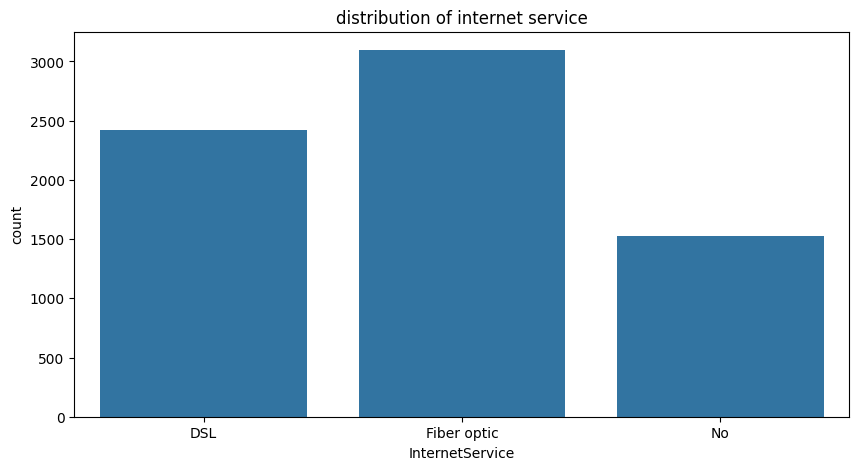

In [17]:
#b. Build a bar-plot to show the distribution of ‘Internet Service’
plt.figure(figsize=(10,5))
sns.countplot(data=df,x=df['InternetService'])
plt.title('distribution of internet service')
plt.show()


In [18]:
#encoding
df['Churn']=df['Churn'].map({'Yes':1,"No":0})

# **Model Building**

In [19]:
x=df[['tenure']]
y=df[['Churn']]

#splitting the data into train and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=44)


In [20]:
model1=Sequential()
model1.add(Dense(12,input_dim=1,activation='relu'))
model1.add(Dense(8,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
model1.compile(optimizer='adam',loss=keras.losses.BinaryCrossentropy(),metrics=['accuracy'])


In [22]:
history=model1.fit(x_train,y_train,epochs=150,validation_data=(x_test,y_test))

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7336 - loss: 0.5219 - val_accuracy: 0.7350 - val_loss: 0.5190
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7345 - loss: 0.5145 - val_accuracy: 0.7350 - val_loss: 0.5187
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7390 - loss: 0.5140 - val_accuracy: 0.7463 - val_loss: 0.5187
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7431 - loss: 0.5139 - val_accuracy: 0.7463 - val_loss: 0.5187
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7444 - loss: 0.5139 - val_accuracy: 0.7463 - val_loss: 0.5187
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7430 - loss: 0.5138 - val_accuracy: 0.7463 - val_loss: 0.5187
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7442 - loss: 0.5138 - val_accuracy: 0.7463 - val_loss: 0.5187
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7442 - loss: 0.5137 - val_a

In [23]:
accuracy=np.mean(history.history['val_accuracy'])
print('the accuracy of the model is :',accuracy)

the accuracy of the model is : 0.7472282687822978


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


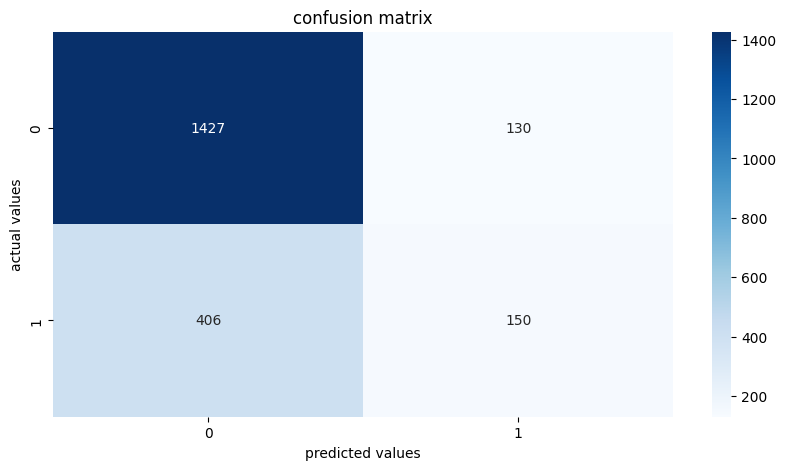

In [24]:
from sklearn.metrics import*
y_pred_prob=model1.predict(x_test)
y_pred=(y_pred_prob>0.5).astype(int)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('predicted values')
plt.ylabel('actual values')
plt.title('confusion matrix')
plt.show()


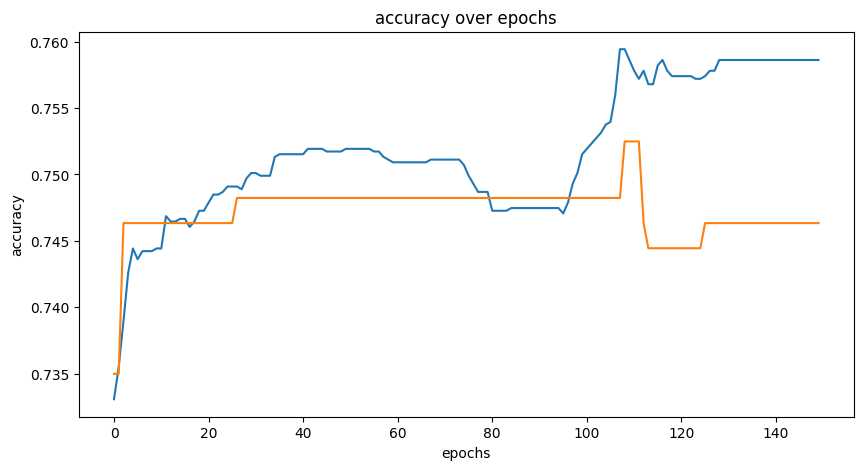

In [25]:
#accuracy vs epochs
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title('accuracy over epochs')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

In [26]:
#model 2
model2=Sequential()
model2.add(Dense(12,input_dim=1,activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(8,activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
model2.compile(optimizer='adam',loss=keras.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [28]:
history=model2.fit(x_train,y_train,epochs=150,validation_data=(x_test,y_test))

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3171 - loss: 13.5344 - val_accuracy: 0.7369 - val_loss: 1.0180
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6243 - loss: 1.9556 - val_accuracy: 0.7369 - val_loss: 1.0929
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6594 - loss: 1.2873 - val_accuracy: 0.7369 - val_loss: 0.8203
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6494 - loss: 0.9470 - val_accuracy: 0.7369 - val_loss: 0.6616
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6578 - loss: 0.7574 - val_accuracy: 0.7369 - val_loss: 0.5743
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6757 - loss: 0.6424 - val_accuracy: 0.7369 - val_loss: 0.5341
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6751 - loss: 0.6389 - val_accuracy: 0.7369 - val_loss: 0.5202
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6953 - loss: 0.6110 - val_acc

In [29]:
accuracy=np.mean(history.history['val_accuracy'])
print('the accuracy of the model is :',accuracy)

the accuracy of the model is : 0.7368670105934143


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


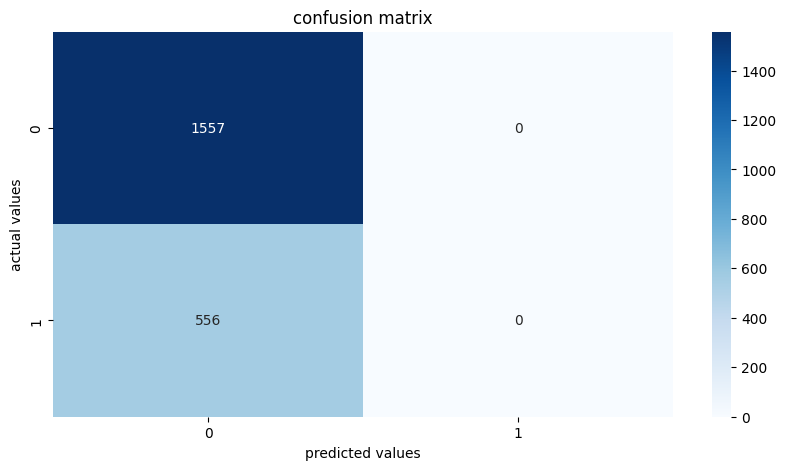

In [30]:
y_pred_prob=model2.predict(x_test)
y_pred=(y_pred_prob>0.5).astype(int)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('predicted values')
plt.ylabel('actual values')
plt.title('confusion matrix')
plt.show()

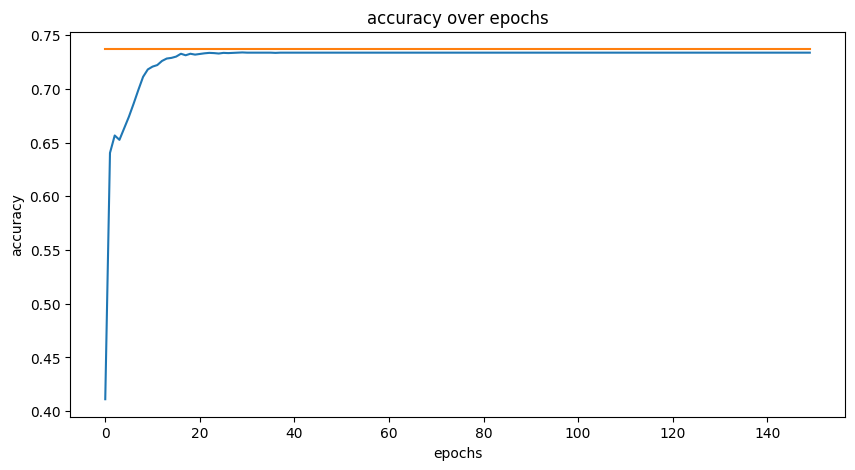

In [31]:
#accuracy vs epochs
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title('accuracy over epochs')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

In [32]:
#model3
x=df[['MonthlyCharges','TotalCharges','tenure']]
y=df[['Churn']]

In [33]:
#splitting the data into train and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=44)

In [34]:
#standardising the valus
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [35]:
model3=Sequential()
model3.add(Dense(12,input_dim=3,activation='relu'))
model3.add(Dense(8,activation='relu'))
model3.add(Dense(1,activation='sigmoid'))

model3.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 12)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
model3.compile(optimizer='adam',loss=keras.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [37]:
history=model3.fit(x_train,y_train,epochs=150,validation_data=(x_test,y_test))

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6895 - loss: 0.6180 - val_accuracy: 0.7369 - val_loss: 0.5237
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7338 - loss: 0.5146 - val_accuracy: 0.7369 - val_loss: 0.4839
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7355 - loss: 0.4850 - val_accuracy: 0.7719 - val_loss: 0.4709
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7831 - loss: 0.4757 - val_accuracy: 0.7875 - val_loss: 0.4643
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7833 - loss: 0.4703 - val_accuracy: 0.7847 - val_loss: 0.4599
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7822 - loss: 0.4664 - val_accuracy: 0.7823 - val_loss: 0.4569
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7799 - loss: 0.4638 - val_accuracy: 0.7814 - val_loss: 0.4549
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7803 - loss: 0.4617 - val_accu

In [38]:
accuracy=np.mean(history.history['val_accuracy'])
print('the accuracy of the model is :',accuracy)

the accuracy of the model is : 0.7854425072669983


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


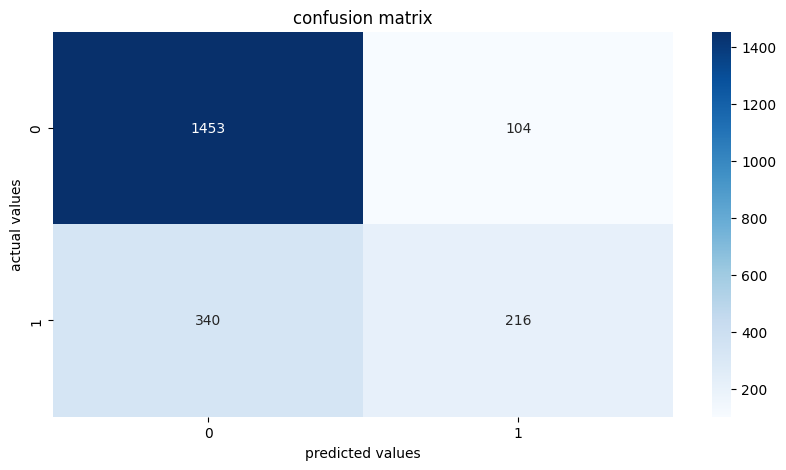

In [39]:
y_pred_prob=model3.predict(x_test)
y_pred=(y_pred_prob>0.5).astype(int)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('predicted values')
plt.ylabel('actual values')
plt.title('confusion matrix')
plt.show()

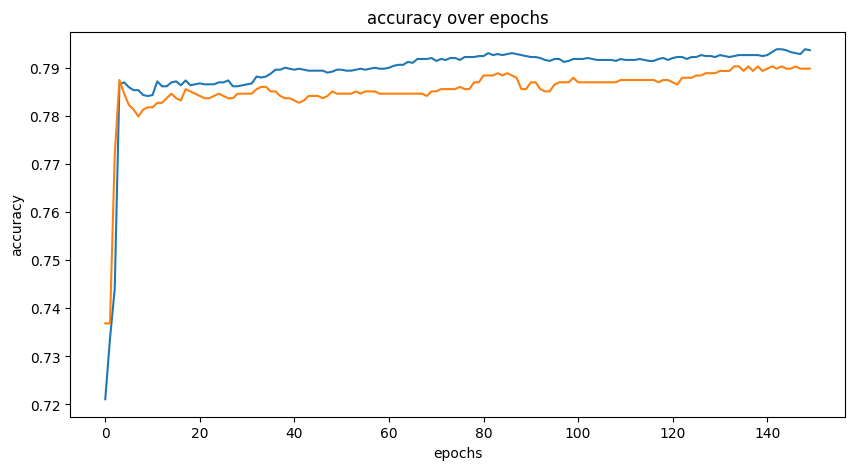

In [40]:
#accuracy vs epochs
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title('accuracy over epochs')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()